# FNO2d Predictions

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
from model_2d import FNO2d, add_grid
from train_utils import UnitGaussianNormalizer, load_data

Slightly altered loss function so we can asses per-sample performance.

In [2]:
def relative_l2(pred, target):
    B = pred.shape[0]
    diff = torch.norm(pred.reshape(B, -1) - target.reshape(B, -1), dim=1)
    tgt = torch.norm(target.reshape(B, -1), dim=1)
    return diff / tgt

In [3]:
mode = 0  # 0 = 241 case, 1 = 421 case

difficulty = ["241", "421"]
res = [241, 421]
s_list = [60, 85] # [40, 60]

case = difficulty[mode]
r = res[mode]
s = s_list[mode]
n_test = 200

TRAIN_PATH = f"data/piececonst_r{case}_N1024_smooth1.mat"
TEST_PATH = f"data/piececonst_r{case}_N1024_smooth2.mat"
MODEL_PATH = f"outputs/fno2d_{case}_final.pt"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [4]:
# Load data
a_train, u_train = load_data(TRAIN_PATH, 1000, r, s)
a_test, u_test = load_data(TEST_PATH, n_test, r, s)
a_normalizer = UnitGaussianNormalizer(a_train)
u_normalizer = UnitGaussianNormalizer(u_train)

a_test_raw = a_test.clone()
a_test = add_grid(a_normalizer.encode(a_test))

model = FNO2d().to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

with torch.no_grad():
    pred_all = u_normalizer.decode(model(a_test.to(device)).cpu())

### Spatial maps

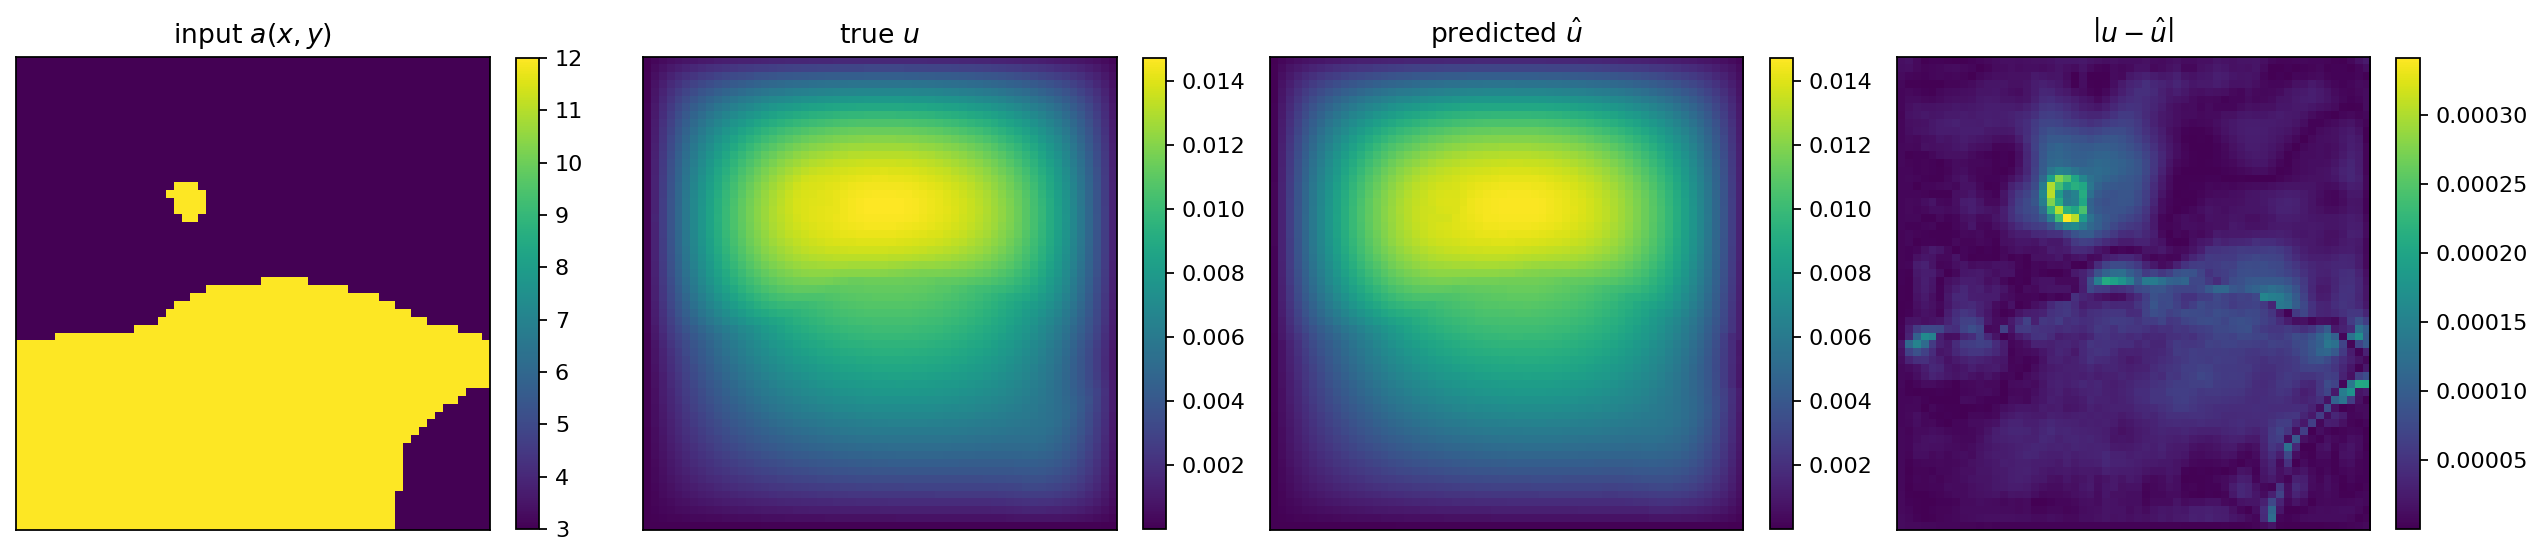

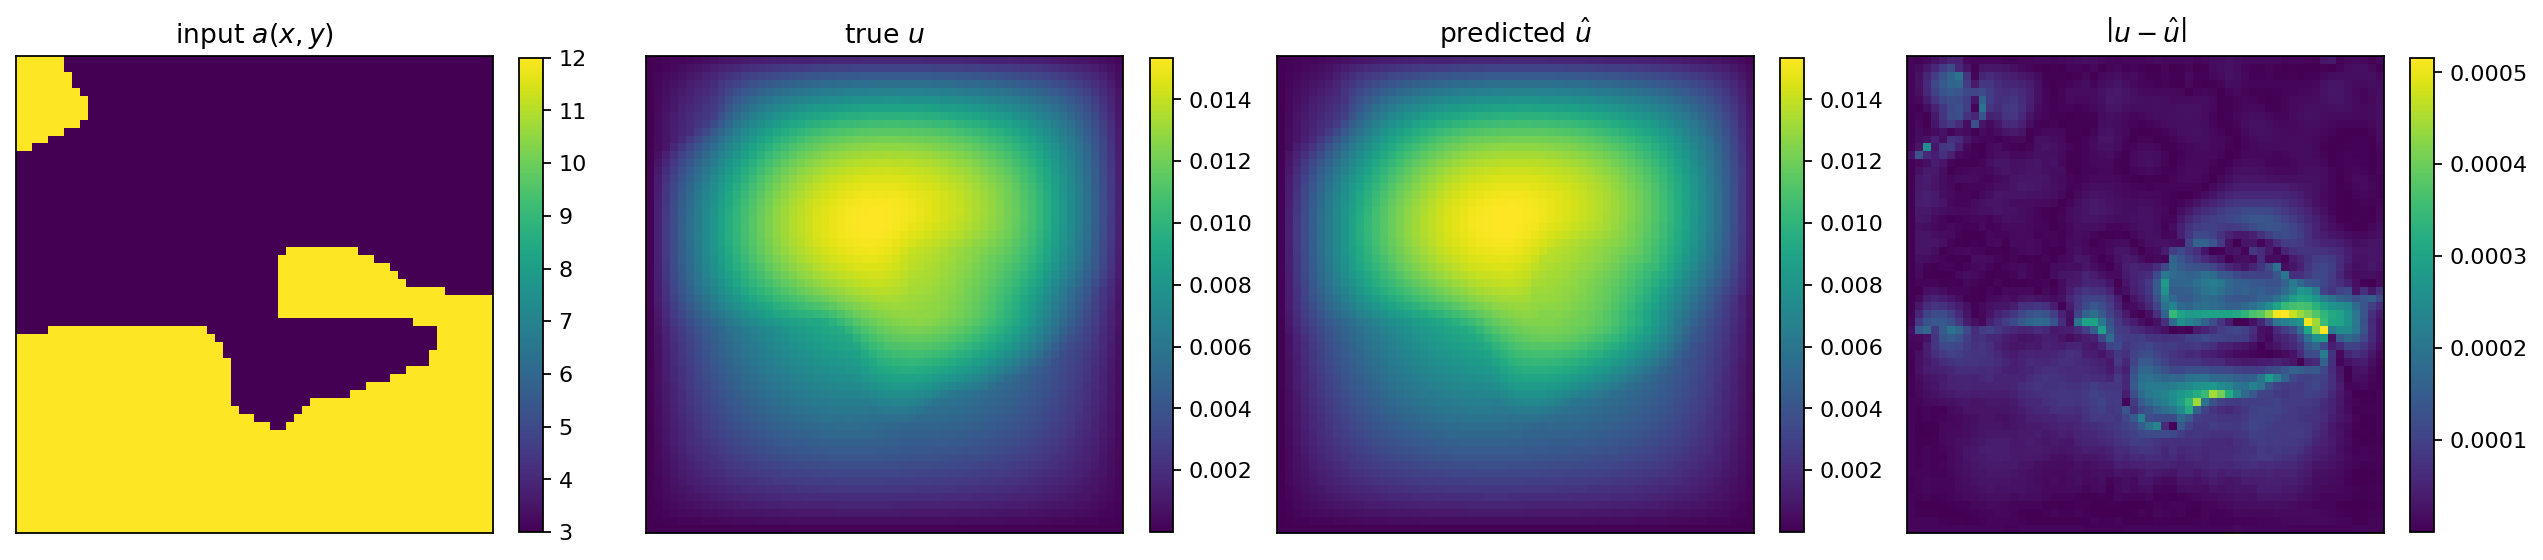

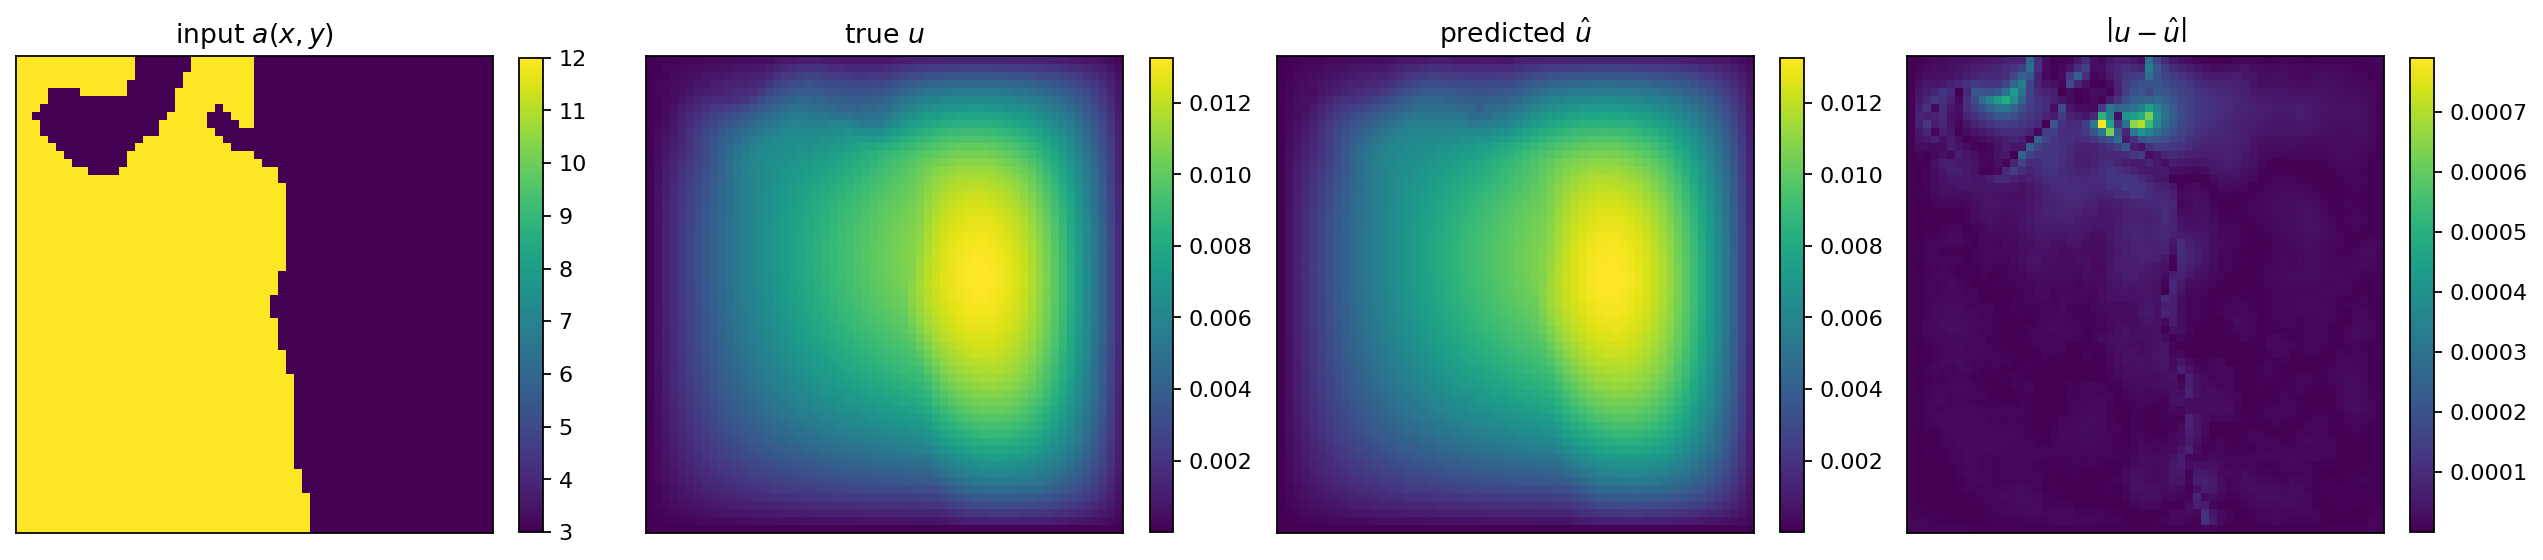

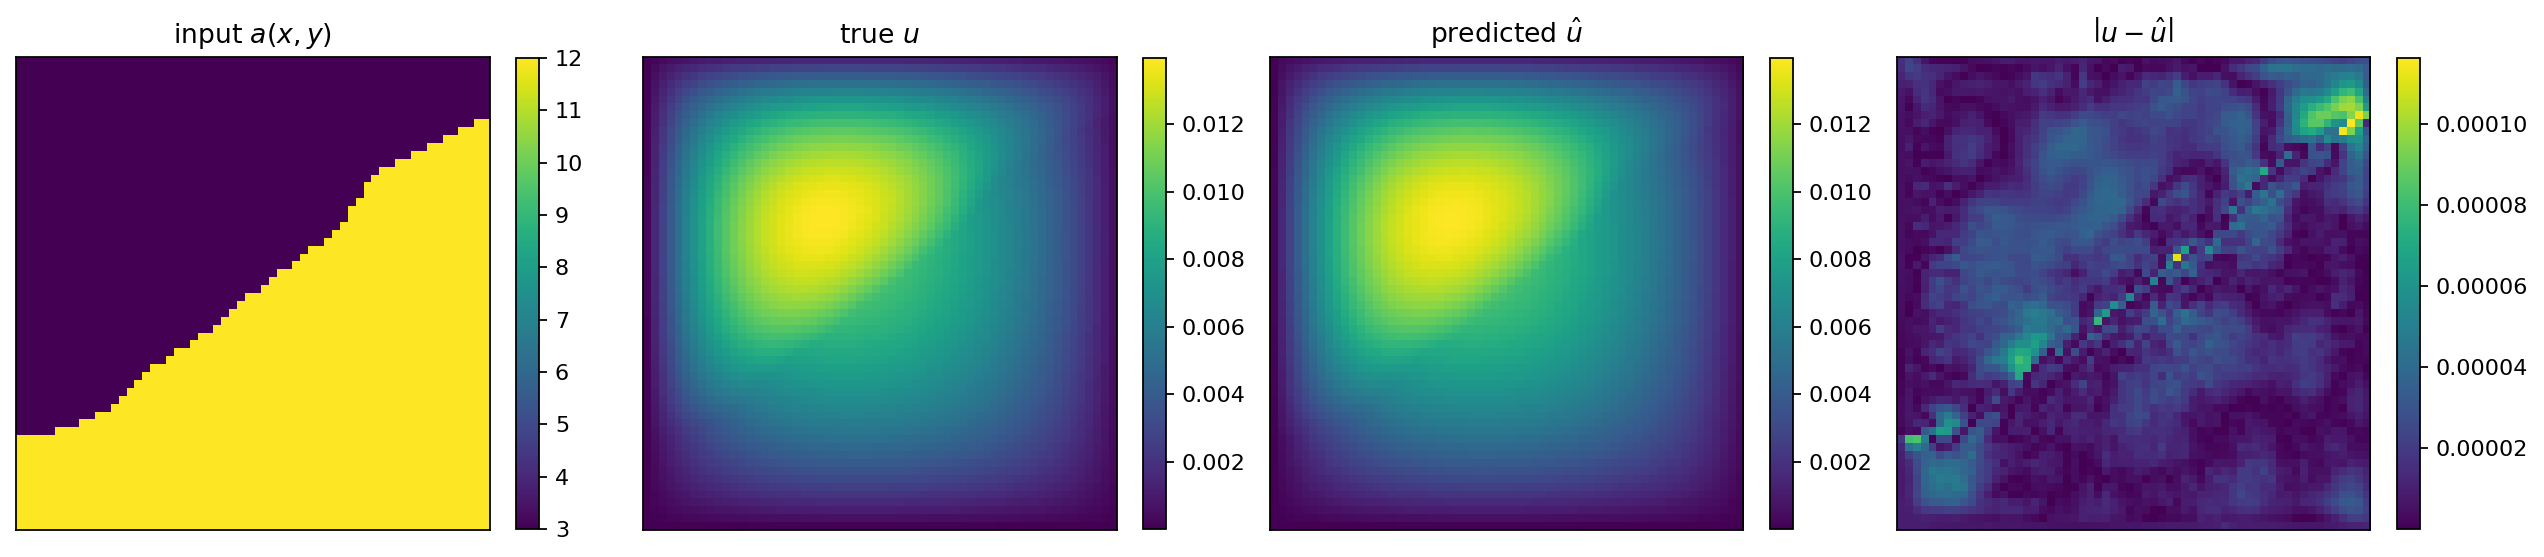

In [5]:
samples = [0, 5, 10, 50] # np.arange(0,50)

for idx in samples:
    a = a_test_raw[idx, 0]
    u = u_test[idx, 0]
    pred = pred_all[idx, 0]
    err = (u - pred).abs()

    fig, axes = subplots(1, 4, figsize=(16, 3.5), dpi=160)
    # fig.suptitle(f"Sample {idx}", fontsize=13, y=1.02)

    im0 = axes[0].imshow(a, origin="lower")
    axes[0].set_title(r"input $a(x,y)$")

    im1 = axes[1].imshow(u, origin="lower")
    axes[1].set_title(r"true $u$")

    im2 = axes[2].imshow(pred, origin="lower", vmin=u.min(), vmax=u.max())
    axes[2].set_title(r"predicted $\hat{u}$")

    im3 = axes[3].imshow(err, origin="lower")
    axes[3].set_title(r"$\left|u-\hat{u}\right|$")

    plt.colorbar(im0, ax=axes[0], fraction=0.045)
    plt.colorbar(im1, ax=axes[1], fraction=0.045)
    plt.colorbar(im2, ax=axes[2], fraction=0.045)
    plt.colorbar(im3, ax=axes[3], fraction=0.045)

    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])

    fig.tight_layout()
    plt.show()